In [1]:
import pickle as pkl
model=pkl.dump(model,open("model.pkl","wb"))
labelEncoder=pkl.dump(labelEncoder,open("labelEncoder.pkl",'wb'))

NameError: name 'model' is not defined

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, precision_score,f1_score,recall_score,classification_report,fbeta_score

In [59]:
# dataset
loan=pd.read_csv("loan_approval_training_dataset.csv")

In [60]:
loan

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loanstatus
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [61]:
# describe
loan.describe()


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [62]:
# handle spaces and other syymbols to columns
loan.columns = loan.columns.str.strip().str.replace(" ", "").str.replace("_", "")
loan.columns = loan.columns.str[0].str.lower() + loan.columns.str[1:]

In [63]:
# Handling spaces for records
for records in loan.columns:
    if loan[records].dtype not in ['int64','float64']:
        loan[records]=loan[records].str.strip()

In [64]:
loan

,loanid,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [65]:
# exclude loadid,cibilscore and loanterm cols
loan=loan.drop(columns=['loanid','cibilscore','loanterm'])

In [66]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,Graduate,No,9600000,29900000,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8200000,700000,14100000,5800000,Approved


In [67]:
# check null values
loan.isnull().sum()
    

noofdependents            0
education                 0
selfemployed              0
incomeannum               0
loanamount                0
residentialassetsvalue    0
commercialassetsvalue     0
luxuryassetsvalue         0
bankassetvalue            0
loanstatus                0
dtype: int64

In [68]:
# extract num and non-num cols
colNum=[cols for cols in loan.columns if loan[cols].dtype!="object"]
# colNum
colText=[columns for columns in loan.columns if loan[columns].dtype not in ["int64","float64"]]
colNum

['noofdependents',
 'incomeannum',
 'loanamount',
 'residentialassetsvalue',
 'commercialassetsvalue',
 'luxuryassetsvalue',
 'bankassetvalue']

In [ ]:
# loan['education'] = loan['education'].map({"Graduate": 1, "Not Graduate": 0})

In [69]:
print(loan['education'].unique())
print(loan['education'].isna().sum())
print(loan.shape)

['Graduate' 'Not Graduate']
0
(4269, 10)


In [70]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,Graduate,No,9600000,29900000,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8200000,700000,14100000,5800000,Approved


In [71]:
# /handling  outliers
for handleOutliers in loan.columns:
    if handleOutliers not in colText:
        Q1=loan[handleOutliers].quantile(0.25)
        Q3=loan[handleOutliers].quantile(0.75)
        IQR=Q3-Q1
    
        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR
        
        countOut=loan.loc[(loan[handleOutliers]<Lower) | (loan[handleOutliers]>Upper)].shape[0]
        if countOut!=0:
            loan[handleOutliers]=loan[handleOutliers].clip(lower=Lower,upper=Upper)

In [72]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,Graduate,No,9600000,29900000,2400000,17050000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8200000,700000,14100000,5800000,Approved


In [73]:

# # encode education and selfemployed columns
loan['education'] = loan['education'].map({"Graduate": 1, "Not Graduate": 0})
loan['selfemployed'] = loan['selfemployed'].map({"Yes": 1, "No": 0})

In [74]:
# Split data
loan['loanstatus']=loan['loanstatus'].str.strip()
x=loan.drop(columns=["loanstatus"])
y=loan["loanstatus"]
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.25,random_state=45)

In [75]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,1,0,9600000,29900000,2400000,17050000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8200000,700000,14100000,5800000,Approved


In [76]:
# Encoder for target var
labelEncoder=LabelEncoder()

In [77]:
# encode yTrain
yTrain=labelEncoder.fit_transform(yTrain)

In [78]:
# encode y test
yTest=labelEncoder.transform(yTest)

In [79]:
xTrain

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue
60,2,0,0,8500000,18900000,23800000,16300000,25900000,11400000
905,5,0,0,9700000,37000000,24950000,17050000,22800000,5600000
2299,2,0,0,900000,2000000,1700000,0,2100000,600000
1576,0,1,1,5900000,15100000,6000000,4300000,14900000,5400000
2790,0,0,1,1000000,3000000,2200000,700000,3500000,900000
...,...,...,...,...,...,...,...,...,...
4111,4,0,0,9700000,31700000,700000,100000,36700000,12000000
3704,1,0,0,2100000,5300000,1500000,3800000,8100000,1700000
580,4,1,1,8900000,26300000,23900000,7000000,27400000,12100000
163,2,0,1,2000000,5300000,4900000,1400000,4300000,2900000


In [80]:
yTrain

array([1, 1, 1, ..., 1, 0, 0], shape=(3201,))

In [81]:
xTrain

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue
60,2,0,0,8500000,18900000,23800000,16300000,25900000,11400000
905,5,0,0,9700000,37000000,24950000,17050000,22800000,5600000
2299,2,0,0,900000,2000000,1700000,0,2100000,600000
1576,0,1,1,5900000,15100000,6000000,4300000,14900000,5400000
2790,0,0,1,1000000,3000000,2200000,700000,3500000,900000
...,...,...,...,...,...,...,...,...,...
4111,4,0,0,9700000,31700000,700000,100000,36700000,12000000
3704,1,0,0,2100000,5300000,1500000,3800000,8100000,1700000
580,4,1,1,8900000,26300000,23900000,7000000,27400000,12100000
163,2,0,1,2000000,5300000,4900000,1400000,4300000,2900000


In [82]:
yTrain

array([1, 1, 1, ..., 1, 0, 0], shape=(3201,))

In [83]:
yTrain=pd.DataFrame(yTrain)

In [84]:
yTrain.columns=['loanstatus']

In [85]:
# check correlation
xTrain.corrwith(yTrain['loanstatus'])

noofdependents            0.032699
education                -0.018698
selfemployed              0.028067
incomeannum               0.026639
loanamount                0.016237
residentialassetsvalue    0.001569
commercialassetsvalue     0.030677
luxuryassetsvalue         0.018477
bankassetvalue            0.023754
dtype: float64

In [86]:
trainingFrame=pd.concat([xTrain.reset_index(drop=True),yTrain.reset_index(drop=True)],axis=1)

In [87]:
trainingFrame

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,0,0,8500000,18900000,23800000,16300000,25900000,11400000,1
1,5,0,0,9700000,37000000,24950000,17050000,22800000,5600000,1
2,2,0,0,900000,2000000,1700000,0,2100000,600000,1
3,0,1,1,5900000,15100000,6000000,4300000,14900000,5400000,0
4,0,0,1,1000000,3000000,2200000,700000,3500000,900000,1
...,...,...,...,...,...,...,...,...,...,...
3196,4,0,0,9700000,31700000,700000,100000,36700000,12000000,1
3197,1,0,0,2100000,5300000,1500000,3800000,8100000,1700000,1
3198,4,1,1,8900000,26300000,23900000,7000000,27400000,12100000,1
3199,2,0,1,2000000,5300000,4900000,1400000,4300000,2900000,0


<Axes: >

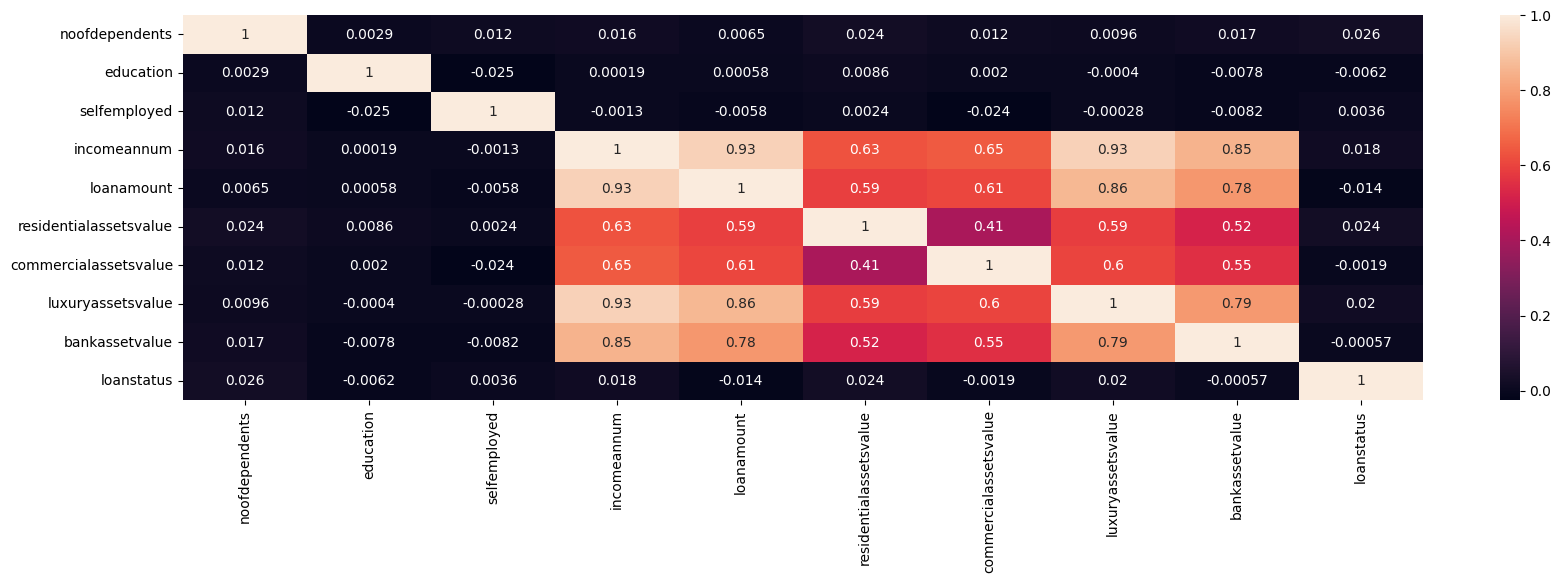

In [88]:
# Corr with heat Map
plt.figure(figsize=(20,5))
sns.heatmap(trainingFrame.corr(),annot=True)

In [113]:
# Realationship is non linear, xgboost is a go to Model
model=XGBClassifier(learning_rate=0.001, 
                    n_estimators=1000,
                    reg_alpha=0.1,
                    reg_lambda=0.1)
model.fit(xTrain,yTrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [114]:
# Prediction
prediction=model.predict(xTest)


In [115]:
# Compute classification report
modelReport=classification_report(yTest,prediction,target_names=labelEncoder.classes_,output_dict=True)

In [116]:
modelReport


{'Approved': {'precision': 0.6162679425837321,
  'recall': 0.9802130898021308,
  'f1-score': 0.7567567567567568,
  'support': 657.0},
 'Rejected': {'precision': 0.43478260869565216,
  'recall': 0.024330900243309004,
  'f1-score': 0.04608294930875576,
  'support': 411.0},
 'accuracy': 0.6123595505617978,
 'macro avg': {'precision': 0.5255252756396921,
  'recall': 0.5022719950227199,
  'f1-score': 0.4014198530327563,
  'support': 1068.0},
 'weighted avg': {'precision': 0.5464266764526452,
  'recall': 0.6123595505617978,
  'f1-score': 0.4832671173736778,
  'support': 1068.0}}

In [117]:
reportFrame=pd.DataFrame(modelReport).transpose()

In [118]:
reportFrame

,precision,recall,f1-score,support
Approved,0.616268,0.980213,0.756757,657.00000
Rejected,0.434783,0.024331,0.046083,411.00000
accuracy,0.612360,0.612360,0.612360,0.61236
macro avg,0.525525,0.502272,0.401420,1068.00000
weighted avg,0.546427,0.612360,0.483267,1068.00000


In [119]:
# computer probability
probability=model.predict_proba(xTest)

In [120]:
model.classes_

array([0, 1])

In [121]:
probability

array([[0.5776158 , 0.4223842 ],
       [0.62617564, 0.3738244 ],
       [0.60111713, 0.3988829 ],
       ...,
       [0.47711033, 0.5228897 ],
       [0.6511725 , 0.34882745],
       [0.7418357 , 0.25816426]], shape=(1068, 2), dtype=float32)

In [122]:
probaFrame=pd.DataFrame(probability,columns=labelEncoder.classes_)

In [123]:
probaFrame

,Approved,Rejected
0,0.577616,0.422384
1,0.626176,0.373824
2,0.601117,0.398883
3,0.612160,0.387840
4,0.577940,0.422060
...,...,...
1063,0.690372,0.309628
1064,0.589243,0.410757
1065,0.477110,0.522890
1066,0.651173,0.348827


In [128]:
# Balanced
fbeta_score(yTest,prediction,beta=1)

0.04608294930875576

In [125]:
# Recall Focused
fbeta_score(yTest,prediction,beta=300)

0.024331155457783846

In [127]:
# Precision
fbeta_score(yTest,prediction,beta=0.5)

0.09940357852882704